# 🎮 Projeto Final — League OF Legends Personagens

## 1. Descrição do Problema

  O objetivo do algoritmo de recomendações, é para que as novas pessoas que querem começar a jogar League of Legends consigam descobrir novos personagens onde o estilo de jogo são parecidos com algum que curtiu. O usuário final é aquela pessoa que curtiu um persoangem do jogo e sua gameplay e gostaria de encontrar outros personagens similares para treinar e aumentar a pool (Quantidade de personagens que joga).
  
  O critério de sucesso para esse projeto é o jogador do jogo conseguir com sucesso as recomendações corretas de personagens novos com base no seu estilo de jogo.


## 2. Carregando o Dataset
O dataset está localizado nesse caminho do github, caso queira utiliza-lo apenas chame esse link: `https://raw.githubusercontent.com/MatheusJosePereira/League-of-Legends-Similaridade-Cosseno/refs/heads/v1/Dados/LoL_champions.csv`.

##Carregando as bibliotecas utilizadas

> Matplotlib - Visualização dos dados em formato de gráfico.

> Pandas - Tratamento, limpeza, modelagem dos dados e visualização de dados em formato de tabela.

> sklearn - Algoritmo de similaridade cosseno


In [94]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [95]:
URL_RAW = "https://raw.githubusercontent.com/MatheusJosePereira/League-of-Legends-Similaridade-Cosseno/refs/heads/v1/Dados/LoL_champions.csv"

In [96]:
df = pd.read_csv(URL_RAW)

## 4. EDA — Análise Exploratória

Para a análise exploratória busquei estar em sintonia com os dados obtidos, estudando-os e verificando sua veracidade para isso busquei alguns personagens de algumas lanes (roles) e virifiquei os status, os tipos de recursos, e as próprias tags se estavam corretas.

Também busquei tratar e limpar dados vazios, no caso desse dataset encontrei dados NULL dentro do campo Resource type, que é nada mais que o tipo de recurso que o personagem usa para gastar suas skills (habilidades) e encontrei alguns campos vazios, porém o motivo disso é porque o personagem realmente não gasta recursos para utilizar suas habilidades, sendo elas de "graça" porém bem balanceadas na hora do jogo alguns exemplos são Alistar, Riven, Katarina e outros.

Vale lembrar que os dados Null dentro dessa coluna foram substituídos para nenhum, ou seja não gasta nenhum tipo de recurso.

### 4.1 Estrutura e tipos

Verificando a estrutura do Dataset e apreciando a organização dos personagens e primeiras ideias sobre utilizar os campos, Role,Resource Type e Range para algoritmo de recomendação (similaridade cosseno).

In [97]:
df.head()

,Name,Tags,Role,Range type,Resourse type,Base HP,HP per lvl,Base mana,Mana per lvl,Movement speed,...,Attack range,HP regeneration,HP regeneration per lvl,Mana regeneration,Mana regeneration per lvl,Attack damage,Attack damage per lvl,Attack speed per lvl,Attack speed,AS ratio
0,Aatrox,Fighter,Top,Melee,Blood Well,650,114,0,0.0,345,...,175,3.00,0.50,0.0,0.0,60,5.00,2.500,0.651,0.651
1,Ahri,"Mage,Assassin",Middle,Ranged,Mana,590,104,418,25.0,330,...,550,2.50,0.60,8.0,0.8,53,3.00,2.200,0.668,0.625
2,Akali,Assassin,"Top,Middle",Melee,Energy,600,119,200,0.0,345,...,125,9.00,0.90,50.0,0.0,62,3.30,3.200,0.625,0.625
3,Akshan,"Marksman,Assassin",Middle,Ranged,Mana,630,107,350,40.0,330,...,500,3.75,0.65,8.2,0.7,52,3.00,4.000,0.638,0.400
4,Alistar,"Tank,Support",Support,Melee,Mana,685,120,350,40.0,330,...,125,8.50,0.85,8.5,0.8,62,3.75,2.125,0.625,0.625


In [98]:
df[['Name', 'Tags', 'Role', 'Range type']].dtypes

,0
Name,object
Tags,object
Role,object
Range type,object


In [99]:
df.isnull().sum()

,0
Name,0
Tags,0
Role,0
Range type,0
Resourse type,7
Base HP,0
HP per lvl,0
Base mana,0
Mana per lvl,0
Movement speed,0


In [100]:
df_null = df[df['Resourse type'].isnull()]

In [101]:
df_null.head(7)

,Name,Tags,Role,Range type,Resourse type,Base HP,HP per lvl,Base mana,Mana per lvl,Movement speed,...,Attack range,HP regeneration,HP regeneration per lvl,Mana regeneration,Mana regeneration per lvl,Attack damage,Attack damage per lvl,Attack speed per lvl,Attack speed,AS ratio
13,Bel'Veth,Fighter,Jungle,Melee,NaN,610,99,60,0.0,340,...,175,6.0,0.6,0.0,0.0,60,1.5,0.00,0.850,0.850
26,Dr. Mundo,"Tank,Fighter",Top,Melee,NaN,613,103,0,0.0,345,...,125,7.0,0.5,0.0,0.0,61,2.5,3.30,0.670,0.625
36,Garen,"Fighter,Tank",Top,Melee,NaN,690,98,0,0.0,340,...,175,8.0,0.5,0.0,0.0,69,4.5,3.65,0.625,0.625
58,Katarina,"Assassin,Mage",Middle,Melee,NaN,672,108,0,0.0,335,...,125,7.5,0.7,0.0,0.0,58,3.2,2.74,0.658,0.658
107,Riven,"Fighter,Assassin",Top,Melee,NaN,630,100,0,0.0,340,...,125,8.5,0.5,0.0,0.0,64,3.0,3.50,0.625,0.625
147,Viego,"Fighter,Assassin",Jungle,Melee,NaN,630,109,0,0.0,345,...,200,7.0,0.7,0.0,0.0,57,3.5,2.50,0.658,0.658
160,Zac,"Tank,Fighter","Jungle,Top,Support",Melee,NaN,685,109,0,0.0,340,...,175,5.0,0.5,0.0,0.0,60,3.4,1.60,0.736,0.638


In [102]:
df['Resourse type'].fillna('Nenhum', inplace=True)

/tmp/ipython-input-769596102.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Resourse type'].fillna('Nenhum', inplace=True)


In [103]:
df['Resourse type'].unique()

array(['Blood Well', 'Mana', 'Energy', 'Nenhum', 'Fury', 'Rage',
       'Courage', 'Shield', 'Ferocity', 'Heat', 'Grit', 'Crimson Rush',
       'Flow'], dtype=object)

##Analisando e tirando conclusões sobre o balanceamento dos personagens no jogo

In [104]:
df_status = df[['Name','Resourse type','Range type','Attack range' ,'Attack damage', 'Attack damage per lvl', 'Attack speed per lvl', 'Attack speed', 'HP regeneration', 'HP regeneration per lvl', 'Mana regeneration per lvl', 'Base mana', 'Base armor', 'Base magic resistance', 'Movement speed']]

In [105]:
df.columns

Index(['Name', 'Tags', 'Role', 'Range type', 'Resourse type', 'Base HP',
       'HP per lvl', 'Base mana', 'Mana per lvl', 'Movement speed',
       'Base armor', 'Armor per lvl', 'Base magic resistance',
       'Magic resistance per lvl', 'Attack range', 'HP regeneration',
       'HP regeneration per lvl', 'Mana regeneration',
       'Mana regeneration per lvl', 'Attack damage', 'Attack damage per lvl',
       'Attack speed per lvl', 'Attack speed', 'AS ratio'],
      dtype='object')

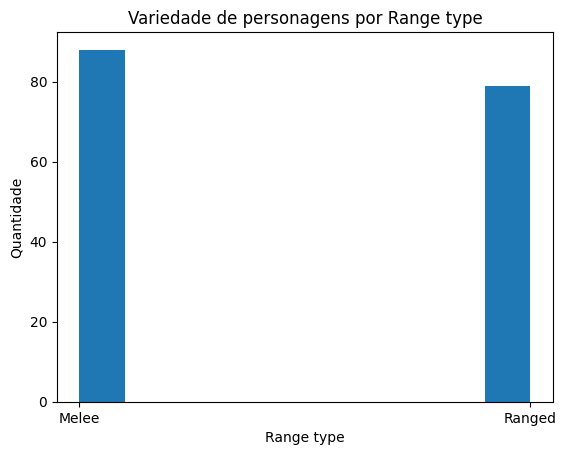

In [106]:
plt.hist(df['Range type'])
plt.title('Variedade de personagens por Range type')
plt.xlabel('Range type')
plt.ylabel('Quantidade')
plt.show()

##Criando dataset Binário

Foi convertido cada valor dentro das colunas escolhidas para binário e substituido true e false para 0 e 1, sendo possível assim aplicar a formula da similaridade cosseno que consiste em "comparar" a direção de 2 vetores e encontrar o angulo que representa a similaridade do conteúdo dos 2 vetores, onde se o valor do angulo se aproximar cada vez mais de +1 quer dizer que são similares agora se estiver se aproximando de 0 quer dizer que eles não tem pontos em comum e caso esteja indo a números negativos quer dizer que eles são opostos:

<img src="https://ichi.pro/assets/images/max/724/1*IhpY-6LYV75983THCpWo-w.png">

Para isso transformei cada tupla (linha) em um vetor respondendo a cada um dos personagens e fui concatenando novas relações que fui descobrindo e concatenando a coluna personagem para eu verificar se ficou correta a construção da tabela binária.

In [107]:
df_binario = pd.get_dummies(df[['Resourse type', 'Range type']])
df_binario = df_binario.astype(int)
df_binario.head()

,Resourse type_Blood Well,Resourse type_Courage,Resourse type_Crimson Rush,Resourse type_Energy,Resourse type_Ferocity,Resourse type_Flow,Resourse type_Fury,Resourse type_Grit,Resourse type_Heat,Resourse type_Mana,Resourse type_Nenhum,Resourse type_Rage,Resourse type_Shield,Range type_Melee,Range type_Ranged
0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
2,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0


In [108]:
df_v1 = pd.concat([df['Name'], df_binario], axis=1)

In [109]:
df_v1.head()

,Name,Resourse type_Blood Well,Resourse type_Courage,Resourse type_Crimson Rush,Resourse type_Energy,Resourse type_Ferocity,Resourse type_Flow,Resourse type_Fury,Resourse type_Grit,Resourse type_Heat,Resourse type_Mana,Resourse type_Nenhum,Resourse type_Rage,Resourse type_Shield,Range type_Melee,Range type_Ranged
0,Aatrox,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,Ahri,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
2,Akali,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
3,Akshan,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
4,Alistar,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0


In [110]:
df_rotas = df['Role'].str.get_dummies(sep=',')

In [115]:
df_v2 = pd.concat([df_v1, df_rotas], axis=1)
df_v2.head()

,Name,Resourse type_Blood Well,Resourse type_Courage,Resourse type_Crimson Rush,Resourse type_Energy,Resourse type_Ferocity,Resourse type_Flow,Resourse type_Fury,Resourse type_Grit,Resourse type_Heat,...,Resourse type_Nenhum,Resourse type_Rage,Resourse type_Shield,Range type_Melee,Range type_Ranged,Bottom,Jungle,Middle,Support,Top
0,Aatrox,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
1,Ahri,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
2,Akali,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,1
3,Akshan,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
4,Alistar,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0


In [116]:
valor = df_v2.drop('Name', axis=1).values
simcos = cosine_similarity(valor)

In [117]:
df_sim = pd.DataFrame(simcos, columns=df_v2['Name'], index=df_v2['Name'])
df_sim.head()

Name,Aatrox,Ahri,Akali,Akshan,Alistar,Amumu,Anivia,Annie,Aphelios,Ashe,...,Yone,Yorick,Yuumi,Zac,Zed,Zeri,Ziggs,Zilean,Zoe,Zyra
Name,,,,,,,,,,,,,,,,,,,,,
Aatrox,1.000000,0.000000,0.577350,0.000000,0.333333,0.288675,0.000000,0.000000,0.000000,0.00000,...,0.577350,0.666667,0.000000,0.516398,0.288675,0.000000,0.000000,0.000000,0.000000,0.000000
Ahri,0.000000,1.000000,0.288675,1.000000,0.333333,0.288675,1.000000,1.000000,0.666667,0.57735,...,0.288675,0.333333,0.666667,0.000000,0.288675,0.666667,0.866025,0.666667,1.000000,0.666667
Akali,0.577350,0.288675,1.000000,0.288675,0.288675,0.250000,0.288675,0.288675,0.000000,0.00000,...,0.750000,0.577350,0.000000,0.447214,0.750000,0.000000,0.250000,0.000000,0.288675,0.000000
Akshan,0.000000,1.000000,0.288675,1.000000,0.333333,0.288675,1.000000,1.000000,0.666667,0.57735,...,0.288675,0.333333,0.666667,0.000000,0.288675,0.666667,0.866025,0.666667,1.000000,0.666667
Alistar,0.333333,0.333333,0.288675,0.333333,1.000000,0.866025,0.333333,0.333333,0.333333,0.57735,...,0.288675,0.666667,0.666667,0.516398,0.288675,0.333333,0.288675,0.666667,0.333333,0.666667


##Aplicação Algoritmo Similaridade Cosseno

Para a interação do usuário criei a função abaixo que primeiro recebe como parâmetros o nome do personagem, o data_frame binário com no total 167 colunas e 167 linhas sendo as comparações de todos os personagens com todos os outros. Após isso chamo o dataframe binário versão 2 que seria a completa no momento que finalizei esse algoritmo, e o valor de personagens que o personagem poderá visualizar caso ele não digite nada, deixei como padrão 5.

A lógica que segui foi a verificação de existência do personagem dentro da base, onde caso não exista é retornado ao usuário que o personagem não foi encontrado.

Depois crio um dataframe com a coluna do personagem escolhido sendo a sim_scores e removo a linha com o valor do próprio personagem para que não apareça o próprio personagem quando o algoritmo recomendador rodar, além disso usei sort_values para organizar a tabela para que seja de fato exibido os personagens com a similaridade mais parecida.

Após isso faço a organização criando uma nova coluna similaridade e incluindo os nomes dos personagens que serão recomendados em um dataframe copia.

In [118]:
df_v2.columns = df_v2.columns.str.lower()

In [119]:
def recomendacao_personagem(name, df_sim, df_v2, top_k=5):
    name = name.strip()
    if name not in df_sim.index:
        raise ValueError(f"Personagem '{name}' não encontrado.")
    sim_scores = df_sim.loc[name]
    top_sim = sim_scores.drop(name).sort_values(ascending=False).head(top_k)
    recomendacao = df_v2[df_v2['name'].isin(top_sim.index)].copy()
    recomendacao.insert(1, 'similaridade', top_sim.values)
    return recomendacao.reset_index(drop=True)


In [120]:
personagem_input = input("Digite o nome do personagem: ")
quantidade_similaridades = int(input("Escreva quantos personagens similares você quer ver: "))

top5 = recomendacao_personagem(personagem_input, df_sim, df_v2, top_k=quantidade_similaridades)
top5.head(quantidade_similaridades)


Digite o nome do personagem: Gragas
Escreva quantos personagens similares você quer ver: 50


,name,similaridade,resourse type_blood well,resourse type_courage,resourse type_crimson rush,resourse type_energy,resourse type_ferocity,resourse type_flow,resourse type_fury,resourse type_grit,...,resourse type_nenhum,resourse type_rage,resourse type_shield,range type_melee,range type_ranged,bottom,jungle,middle,support,top
0,Cho'Gath,0.912871,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
1,Darius,0.894427,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,Diana,0.894427,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,1,0,0
3,Ekko,0.894427,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,1,0,0
4,Evelynn,0.894427,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
5,Fiora,0.894427,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
6,Fizz,0.894427,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
7,Gangplank,0.894427,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
8,Gwen,0.894427,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
9,Hecarim,0.894427,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
